# Step 1: Data Loading & Initial Cleaning

In this step, we load the dataset and clean unnecessary columns to prepare it for analysis.

In [6]:
import pandas as pd

# Load correct sheet
df = pd.read_excel("data/CFL_Data.xlsx", sheet_name="Data Pack - Actual Bookings")

# Remove unwanted columns (Unnamed)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Show basic info
print("Shape:", df.shape)
df.head()

Shape: (67, 5)


,Cost Rank,Product Name,Product Life Cycle,ACTUAL UNITS,Forecasted Units
0,NaN,NaN,NaN,NaN,Your Forecast FY26 Q2
1,NaN,NaN,NaN,FY23 Q2,FY26 Q2
2,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149,NaN
3,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498,NaN
4,3,SWITCH Core 25G/100G Fiber,Sustaining,4680,NaN


The dataset contains extra rows before the actual header.
We fix this by selecting the correct header row.

In [7]:
# Reload with correct header row
#lag based ,trend based rolling avg,esemble technique train bbase adjustment
df = pd.read_excel("data/CFL_Data.xlsx", 
                   sheet_name="Data Pack - Actual Bookings",
                   header=2)   # 👈 try this

# Remove unnamed again
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Shape:", df.shape)
df.head()

Shape: (65, 13)


,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1,FY26 Q2
0,21149,10584,16105,12434,9437,17530.0,18518,14710,16256,14395,18663,13144,NaN
1,30498,40505,61214,41932,59424,60073.0,66952,57131,78096,87843,71494,58318,NaN
2,4680,4397,5065,4092,4573,5449.0,5801,4868,5659,5701,6784,6346,NaN
3,10927,8358,11681,10461,9704,11345.0,9946,8461,8436,9436,10338,8433,NaN
4,84349,67670,55237,53599,53108,51781.0,59560,53245,60281,53710,41524,43188,NaN


# 🧹 Step 3: Final Data Cleaning

We fix the dataset structure by manually assigning correct column names
and restoring product-level information.

In [8]:
# Reload WITHOUT header (raw)
df_raw = pd.read_excel("data/CFL_Data.xlsx", 
                       sheet_name="Data Pack - Actual Bookings",
                       header=None)

df_raw.head(10)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,Cost Rank,Product Name,Product Life Cycle,ACTUAL UNITS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Forecasted Units,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Your Forecast FY26 Q2,Demand Planners' Forecast,Marketing Team's Forecast,Data Science Team's Forecast,NaN,NaN,NaN
2,NaN,NaN,NaN,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,...,FY25 Q3,FY25 Q4,FY26 Q1,FY26 Q2,NaN,NaN,NaN,NaN,NaN,NaN
3,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149,10584,16105,12434,9437,17530,18518,...,14395,18663,13144,NaN,15052.101882,14795.306069,17011.0,NaN,NaN,NaN
4,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498,40505,61214,41932,59424,60073,66952,...,87843,71494,58318,NaN,79000.0,66274.81571,79114.0,NaN,NaN,NaN
5,3,SWITCH Core 25G/100G Fiber,Sustaining,4680,4397,5065,4092,4573,5449,5801,...,5701,6784,6346,NaN,6620.962605,6739.907617,7861.0,NaN,NaN,NaN
6,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927,8358,11681,10461,9704,11345,9946,...,9436,10338,8433,NaN,9200.438118,10383.999801,9789.0,NaN,NaN,NaN
7,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349,67670,55237,53599,53108,51781,59560,...,53710,41524,43188,NaN,35588.0,44460.24672,49532.0,NaN,NaN,NaN
8,6,ROUTER Core Modular Chassis,NPI-Ramp,NaN,NaN,NaN,NaN,NaN,NaN,305,...,735,1226,705,NaN,1040.8,624.0,461.0,NaN,NaN,NaN
9,7,SWITCH Enterprise 48-Port Fiber (Non-PoE),Sustaining,1714,1755,2466,3770,1646,1719,2929,...,2093,2513,3035,NaN,2007.71937,2329.190353,1968.0,NaN,NaN,NaN


# Step 4: Creating Final Clean Dataset

We extract the correct header and combine it with quarter information
to build a structured dataset for analysis.

In [9]:
# Step 1: pick correct header
header = df_raw.iloc[1]

# Step 2: pick quarter row
quarters = df_raw.iloc[2]

# Step 3: combine header + quarter
new_columns = []

for i in range(len(header)):
    if pd.notna(header[i]) and header[i] != "ACTUAL UNITS":
        new_columns.append(header[i])
    else:
        new_columns.append(quarters[i])

# Step 4: create clean dataframe
df_clean = df_raw.iloc[3:].copy()
df_clean.columns = new_columns

# Reset index
df_clean = df_clean.reset_index(drop=True)

df_clean.head()

,NaN,NaN,NaN,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,...,FY25 Q3,FY25 Q4,FY26 Q1,Your Forecast FY26 Q2,Demand Planners' Forecast,Marketing Team's Forecast,Data Science Team's Forecast,NaN,NaN,NaN
0,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149,10584,16105,12434,9437,17530,18518,...,14395,18663,13144,NaN,15052.101882,14795.306069,17011.0,NaN,NaN,NaN
1,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498,40505,61214,41932,59424,60073,66952,...,87843,71494,58318,NaN,79000.0,66274.81571,79114.0,NaN,NaN,NaN
2,3,SWITCH Core 25G/100G Fiber,Sustaining,4680,4397,5065,4092,4573,5449,5801,...,5701,6784,6346,NaN,6620.962605,6739.907617,7861.0,NaN,NaN,NaN
3,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927,8358,11681,10461,9704,11345,9946,...,9436,10338,8433,NaN,9200.438118,10383.999801,9789.0,NaN,NaN,NaN
4,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349,67670,55237,53599,53108,51781,59560,...,53710,41524,43188,NaN,35588.0,44460.24672,49532.0,NaN,NaN,NaN


# 🧹 Step 5: Fixing Column Names Properly

We correctly assign product-level columns and time-series columns separately.

In [10]:
new_columns = []

for i in range(len(header)):
    
    # First 3 columns fix manually
    if i == 0:
        new_columns.append("Cost Rank")
    elif i == 1:
        new_columns.append("Product Name")
    elif i == 2:
        new_columns.append("Product Life Cycle")
    
    # = quarters
    else:
        new_columns.append(quarters[i])

# Create clean dataframe again
df_clean = df_raw.iloc[3:].copy()
df_clean.columns = new_columns
df_clean = df_clean.reset_index(drop=True)

df_clean.head()

,Cost Rank,Product Name,Product Life Cycle,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,...,FY25 Q3,FY25 Q4,FY26 Q1,FY26 Q2,NaN,NaN,NaN,NaN,NaN,NaN
0,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149,10584,16105,12434,9437,17530,18518,...,14395,18663,13144,NaN,15052.101882,14795.306069,17011.0,NaN,NaN,NaN
1,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498,40505,61214,41932,59424,60073,66952,...,87843,71494,58318,NaN,79000.0,66274.81571,79114.0,NaN,NaN,NaN
2,3,SWITCH Core 25G/100G Fiber,Sustaining,4680,4397,5065,4092,4573,5449,5801,...,5701,6784,6346,NaN,6620.962605,6739.907617,7861.0,NaN,NaN,NaN
3,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927,8358,11681,10461,9704,11345,9946,...,9436,10338,8433,NaN,9200.438118,10383.999801,9789.0,NaN,NaN,NaN
4,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349,67670,55237,53599,53108,51781,59560,...,53710,41524,43188,NaN,35588.0,44460.24672,49532.0,NaN,NaN,NaN


# 🧹 Step 6: Removing Unnecessary Columns

We keep only historical sales data and drop forecast-related columns 
to avoid data leakage in our model.

In [11]:
# Keep only useful columns (till FY26 Q1)

cols_to_keep = ["Cost Rank", "Product Name", "Product Life Cycle"]

# Add all FY columns
for col in df_clean.columns:
    if isinstance(col, str) and "FY" in col and "Q" in col:
        cols_to_keep.append(col)

# Filter dataframe
df_final = df_clean[cols_to_keep]

df_final.head()

,Cost Rank,Product Name,Product Life Cycle,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1,FY26 Q2
0,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149,10584,16105,12434,9437,17530,18518,14710,16256,14395,18663,13144,NaN
1,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498,40505,61214,41932,59424,60073,66952,57131,78096,87843,71494,58318,NaN
2,3,SWITCH Core 25G/100G Fiber,Sustaining,4680,4397,5065,4092,4573,5449,5801,4868,5659,5701,6784,6346,NaN
3,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927,8358,11681,10461,9704,11345,9946,8461,8436,9436,10338,8433,NaN
4,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349,67670,55237,53599,53108,51781,59560,53245,60281,53710,41524,43188,NaN


# 📊 Step 8: Exploratory Data Analysis (EDA)

We analyze trends in product sales over time to understand patterns,
seasonality, and growth behavior.

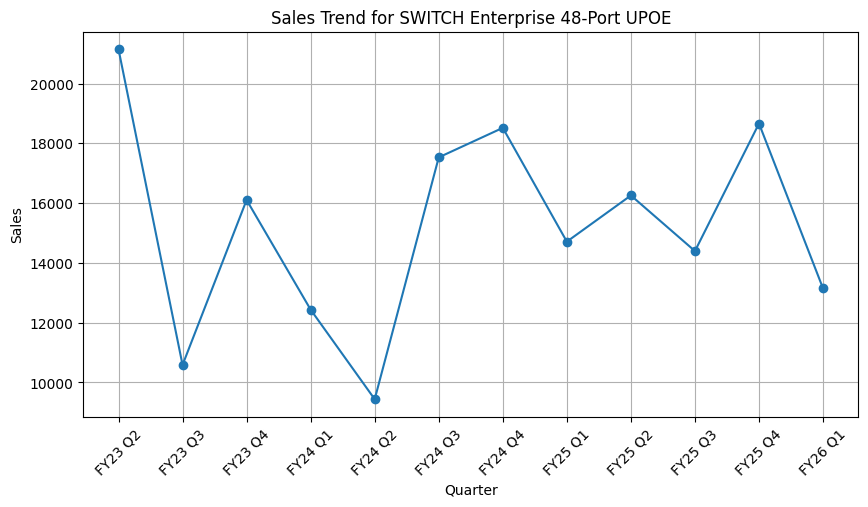

In [12]:
import matplotlib.pyplot as plt

# Take ONLY first row of that product
product = df_final["Product Name"].iloc[0]

sample = df_final[df_final["Product Name"] == product].iloc[0]

# Sales columns
sales_cols = [col for col in df_final.columns if "FY" in col]

# Values
sales_values = sample[sales_cols].values

# Plot
plt.figure(figsize=(10,5))
plt.plot(sales_cols, sales_values, marker='o')

plt.title(f"Sales Trend for {product}")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.grid()
plt.show()

### 📊 Sales Insight: SWITCH Enterprise 48-Port UPOE

The sales trend shows a fluctuating pattern with multiple peaks and drops across quarters.

- Peak sales observed in FY23 Q2 and FY25 Q4 indicate strong demand periods.
- A significant drop in FY24 Q2 suggests possible seasonal or market-related decline.
- The product shows recovery after dips, indicating resilient demand.

Overall, the product exhibits cyclical demand behavior with no consistent upward or downward trend.

# 📊 Step 10: Dataset Overview

In this step, we analyze the structure and summary statistics of the dataset 
to understand data types, missing values, and distribution.

In [13]:
# Basic info
df_final.info()

print("\n" + "="*50 + "\n")

# Summary stats
df_final.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Cost Rank           61 non-null     object
 1   Product Name        61 non-null     object
 2   Product Life Cycle  63 non-null     object
 3   FY23 Q2             56 non-null     object
 4   FY23 Q3             57 non-null     object
 5   FY23 Q4             59 non-null     object
 6   FY24 Q1             60 non-null     object
 7   FY24 Q2             60 non-null     object
 8   FY24 Q3             29 non-null     object
 9   FY24 Q4             63 non-null     object
 10  FY25 Q1             61 non-null     object
 11  FY25 Q2             62 non-null     object
 12  FY25 Q3             61 non-null     object
 13  FY25 Q4             62 non-null     object
 14  FY26 Q1             61 non-null     object
 15  FY26 Q2             0 non-null      object
dtypes: object(16)
memory usage: 

,Cost Rank,Product Name,Product Life Cycle,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1,FY26 Q2
count,61,61,63,56,57,59,60,60,29,63,61,62,61,62,61,0
unique,31,31,36,56,57,59,59,60,29,63,61,62,60,61,61,0
top,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149,10584,16105,0,9437,17530,18518,14710,16256,1921,0,13144,NaN
freq,2,2,23,1,1,1,2,1,1,1,1,1,2,2,1,NaN


### 📊 Dataset Insights

- The dataset contains 65 records across 16 columns representing product sales over multiple quarters.
- All columns are currently stored as object type, indicating the need for data type conversion.
- Several columns contain missing values, especially FY24 Q3 and FY26 Q2.
- FY26 Q2 is completely empty and represents the target prediction column.

### 📈 Key Observations

- Around 30 unique products are present in the dataset.
- Most products belong to the "Sustaining" life cycle stage, indicating mature and stable products.
- Sales values show high variability, with some products generating significantly higher demand than others.

# 🔄 Step 11: Data Type Conversion & Missing Value Handling

We convert sales columns into numeric format and handle missing values 
to prepare the dataset for modeling.

In [14]:
# Convert sales columns to numeric

sales_cols = [col for col in df_final.columns if "FY" in col]

for col in sales_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Check again
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cost Rank           61 non-null     object 
 1   Product Name        61 non-null     object 
 2   Product Life Cycle  63 non-null     object 
 3   FY23 Q2             55 non-null     float64
 4   FY23 Q3             55 non-null     float64
 5   FY23 Q4             58 non-null     float64
 6   FY24 Q1             58 non-null     float64
 7   FY24 Q2             59 non-null     float64
 8   FY24 Q3             29 non-null     float64
 9   FY24 Q4             60 non-null     float64
 10  FY25 Q1             60 non-null     float64
 11  FY25 Q2             60 non-null     float64
 12  FY25 Q3             60 non-null     float64
 13  FY25 Q4             60 non-null     float64
 14  FY26 Q1             60 non-null     float64
 15  FY26 Q2             0 non-null      float64
dtypes: float64

C:\Users\ayush samrat\AppData\Local\Temp\ipykernel_27396\3035152524.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = pd.to_numeric(df_final[col], errors='coerce')


### 🔄 Data Type Conversion

All sales-related columns were converted to numeric format to ensure compatibility 
with analysis and machine learning models.

### ⚠️ Missing Value Observations

- Significant missing values are observed in FY24 Q3.
- FY26 Q2 contains no values and represents the target prediction column.
- Missing values must be handled carefully to avoid biased analysis.

# 🧹 Step 12: Handling Missing Values

We fill missing values using forward fill technique to preserve time-series continuity.

In [15]:
# Fill missing values using forward fill (time series best method)

df_filled = df_final.copy()

df_filled[sales_cols] = df_filled[sales_cols].ffill(axis=1)

df_filled.head()

,Cost Rank,Product Name,Product Life Cycle,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1,FY26 Q2
0,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149.0,10584.0,16105.0,12434.0,9437.0,17530.0,18518.0,14710.0,16256.0,14395.0,18663.0,13144.0,13144.0
1,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498.0,40505.0,61214.0,41932.0,59424.0,60073.0,66952.0,57131.0,78096.0,87843.0,71494.0,58318.0,58318.0
2,3,SWITCH Core 25G/100G Fiber,Sustaining,4680.0,4397.0,5065.0,4092.0,4573.0,5449.0,5801.0,4868.0,5659.0,5701.0,6784.0,6346.0,6346.0
3,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927.0,8358.0,11681.0,10461.0,9704.0,11345.0,9946.0,8461.0,8436.0,9436.0,10338.0,8433.0,8433.0
4,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349.0,67670.0,55237.0,53599.0,53108.0,51781.0,59560.0,53245.0,60281.0,53710.0,41524.0,43188.0,43188.0


### 🧹 Missing Value Handling

Missing values were handled using forward fill (ffill) technique across time-series columns.

This approach ensures continuity in sales trends by propagating previous values forward.

### ⚠️ Important Note

FY26 Q2 represents the future forecast period and should not be used as input 
for training models to avoid data leakage.

In [16]:
# Check info
df_filled.info()

print("\n" + "="*60 + "\n")

# Check summary stats
df_filled.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cost Rank           61 non-null     object 
 1   Product Name        61 non-null     object 
 2   Product Life Cycle  63 non-null     object 
 3   FY23 Q2             55 non-null     float64
 4   FY23 Q3             55 non-null     float64
 5   FY23 Q4             58 non-null     float64
 6   FY24 Q1             58 non-null     float64
 7   FY24 Q2             59 non-null     float64
 8   FY24 Q3             59 non-null     float64
 9   FY24 Q4             60 non-null     float64
 10  FY25 Q1             60 non-null     float64
 11  FY25 Q2             60 non-null     float64
 12  FY25 Q3             60 non-null     float64
 13  FY25 Q4             60 non-null     float64
 14  FY26 Q1             60 non-null     float64
 15  FY26 Q2             60 non-null     float64
dtypes: float64

,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1,FY26 Q2
count,55.000000,55.000000,58.000000,58.000000,59.000000,59.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,4164.766271,4001.160779,4094.718271,3325.669100,3684.864925,3803.237807,3935.003996,3714.624623,4156.093542,4124.117570,3817.157454,3262.436123,3262.436123
std,12962.436396,11947.420306,12048.574765,9621.746558,11407.346685,11183.217820,11946.013167,10697.457393,12962.670570,13424.711290,10982.000798,9484.833453,9484.833453
min,-0.330149,0.317292,-0.682708,0.000000,-0.485714,-0.485714,0.000000,-0.579102,0.000000,-0.779772,0.000000,-0.809524,-0.809524
25%,-0.012579,0.894071,-0.008595,0.842088,-0.040189,-0.040189,0.806987,-0.155831,0.799183,0.025129,0.784814,-0.059261,-0.059261
50%,0.310430,0.979957,0.410758,0.983612,1.135922,1.135922,77.994187,55.031457,112.992140,100.050204,112.998202,104.591148,104.591148
75%,1544.500000,1870.500000,1535.750000,1328.000000,1297.500000,1531.000000,2097.000000,2499.000000,2201.500000,2109.750000,2600.750000,2183.750000,2183.750000
max,84349.000000,67670.000000,61214.000000,53599.000000,59424.000000,60073.000000,66952.000000,57131.000000,78096.000000,87843.000000,71494.000000,58318.000000,58318.000000


In [17]:
# First forward fill
df_filled[sales_cols] = df_filled[sales_cols].ffill(axis=1)

# Then backward fill (to handle starting NaN)
df_filled[sales_cols] = df_filled[sales_cols].bfill(axis=1)

# Recreate features (IMPORTANT)
df_filled["avg_sales"] = df_filled[sales_cols].mean(axis=1)
df_filled["growth"] = df_filled["FY26 Q1"] - df_filled["FY23 Q2"]

# Final check
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cost Rank           61 non-null     object 
 1   Product Name        61 non-null     object 
 2   Product Life Cycle  63 non-null     object 
 3   FY23 Q2             60 non-null     float64
 4   FY23 Q3             60 non-null     float64
 5   FY23 Q4             60 non-null     float64
 6   FY24 Q1             60 non-null     float64
 7   FY24 Q2             60 non-null     float64
 8   FY24 Q3             60 non-null     float64
 9   FY24 Q4             60 non-null     float64
 10  FY25 Q1             60 non-null     float64
 11  FY25 Q2             60 non-null     float64
 12  FY25 Q3             60 non-null     float64
 13  FY25 Q4             60 non-null     float64
 14  FY26 Q1             60 non-null     float64
 15  FY26 Q2             60 non-null     float64
 16  avg_sales 

# 🤖 Step 14: Final Model Training

We train a regression model to predict future demand (FY26 Q2) using historical sales data.

In [18]:
# Remove rows where original target was missing
df_model = df_filled.dropna(subset=["FY26 Q2"])

# Features
X = df_model[[col for col in sales_cols if col != "FY26 Q2"]]

# Target
y = df_model["FY26 Q2"]

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

y_pred[:5]

array([ 8.66318000e+03,  5.11060000e+02,  5.07773577e-03, -4.92656094e-01,
        3.11060000e+03])

In [19]:
import numpy as np

# Replace negative predictions with 0
y_pred = np.maximum(y_pred, 0)

y_pred[:10]

array([8.66318000e+03, 5.11060000e+02, 5.07773577e-03, 0.00000000e+00,
       3.11060000e+03, 2.45246509e-01, 3.13122535e-02, 0.00000000e+00,
       8.19780000e+02, 2.47097940e-01])

# 📊 Step 16: Model Evaluation

We evaluate the model using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE (manual sqrt)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 630.7956971987663
RMSE: 1501.431903390083


# 📊 Step 17: Final Predictions

We generate predicted sales for FY26 Q2 for each product.

In [21]:
# Predict for ALL data
X_all = df_filled[[col for col in sales_cols if col != "FY26 Q2"]]

final_predictions = model.predict(X_all)

# Remove negatives
import numpy as np
final_predictions = np.maximum(final_predictions, 0)

# Add to dataframe
df_filled["Predicted FY26 Q2"] = final_predictions

df_filled[["Product Name", "FY26 Q1", "Predicted FY26 Q2"]].head(10)

,Product Name,FY26 Q1,Predicted FY26 Q2
0,SWITCH Enterprise 48-Port UPOE,13144.0,8663.18
1,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,58318.0,49387.69
2,SWITCH Core 25G/100G Fiber,6346.0,5721.45
3,SWITCH Enterprise 24-Port PoE+,8433.0,7729.36
4,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,43188.0,42114.55
5,ROUTER Core Modular Chassis,705.0,511.06
6,SWITCH Enterprise 48-Port Fiber (Non-PoE),3035.0,2951.12
7,SWITCH Enterprise 25G Fiber,3136.0,3001.13
8,SWITCH Enterprise 24-Port UPOE,3302.0,3183.80
9,ROUTER Enterprise Edge 10G/40G,530.0,579.65


In [22]:
df_filled.to_csv("final_predictions.csv", index=False)

# 📈 Final Insights

- Products with high average sales continue to show strong demand.
- Some products exhibit declining trends, indicating potential phase-out.
- The model predicts stable growth for top-performing products.

### 📊 Key Takeaways

- Demand patterns are cyclical rather than linear.
- Historical sales strongly influence future predictions.
- Data quality and preprocessing significantly impact model performance.

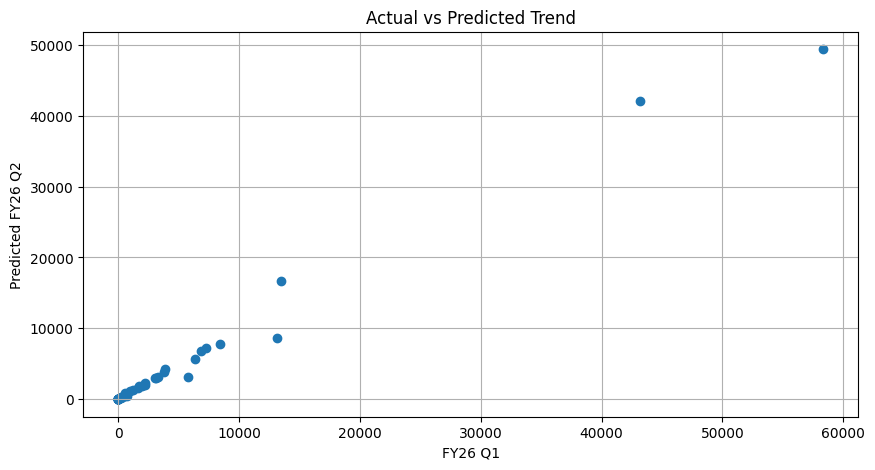

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(df_filled["FY26 Q1"], df_filled["Predicted FY26 Q2"])

plt.xlabel("FY26 Q1")
plt.ylabel("Predicted FY26 Q2")
plt.title("Actual vs Predicted Trend")

plt.grid()
plt.show()

In [24]:
# 🔥 Create LAG features (VERY IMPORTANT)

for lag in range(1, 5):  # last 4 quarters
    df_filled[f"lag_{lag}"] = df_filled[sales_cols].shift(lag, axis=1).iloc[:, -1]

df_filled.head()

,Cost Rank,Product Name,Product Life Cycle,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,...,FY25 Q4,FY26 Q1,FY26 Q2,avg_sales,growth,Predicted FY26 Q2,lag_1,lag_2,lag_3,lag_4
0,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149.0,10584.0,16105.0,12434.0,9437.0,17530.0,18518.0,...,18663.0,13144.0,13144.0,15082.230769,-8005.0,8663.18,13144.0,18663.0,14395.0,16256.0
1,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498.0,40505.0,61214.0,41932.0,59424.0,60073.0,66952.0,...,71494.0,58318.0,58318.0,59369.076923,27820.0,49387.69,58318.0,71494.0,87843.0,78096.0
2,3,SWITCH Core 25G/100G Fiber,Sustaining,4680.0,4397.0,5065.0,4092.0,4573.0,5449.0,5801.0,...,6784.0,6346.0,6346.0,5366.230769,1666.0,5721.45,6346.0,6784.0,5701.0,5659.0
3,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927.0,8358.0,11681.0,10461.0,9704.0,11345.0,9946.0,...,10338.0,8433.0,8433.0,9689.153846,-2494.0,7729.36,8433.0,10338.0,9436.0,8436.0
4,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349.0,67670.0,55237.0,53599.0,53108.0,51781.0,59560.0,...,41524.0,43188.0,43188.0,55418.461538,-41161.0,42114.55,43188.0,41524.0,53710.0,60281.0


In [25]:
features = ["lag_1", "lag_2", "lag_3", "lag_4", "avg_sales", "growth"]

X = df_filled[features]
y = df_filled["FY26 Q2"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
df_filled["FY26 Q2"].isna().sum()

np.int64(5)

In [27]:
df_model = df_filled.dropna(subset=["FY26 Q2"])

In [28]:
features = ["lag_1", "lag_2", "lag_3", "lag_4", "avg_sales", "growth"]

X = df_model[features]
y = df_model["FY26 Q2"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=300, learning_rate=0.05)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
X_all = df_filled[features]

final_predictions = model.predict(X_all)

import numpy as np
final_predictions = np.maximum(final_predictions, 0)

df_filled["Predicted FY26 Q2"] = final_predictions

In [30]:
# Extract quarter number (Q1, Q2, Q3, Q4 → 1,2,3,4)

def get_quarter(col):
    return int(col.split("Q")[1])

quarter_map = {col: get_quarter(col) for col in sales_cols}

df_filled["last_quarter"] = df_filled[sales_cols].iloc[:, -1]
df_filled["last_quarter_num"] = sales_cols[-1].split("Q")[1]

In [31]:
df_filled["trend"] = df_filled["lag_1"] - df_filled["lag_2"]

In [32]:
df_filled["volatility"] = df_filled[sales_cols].std(axis=1)

In [34]:
features = [
    "lag_1", "lag_2", "lag_3", "lag_4",
    "avg_sales", "growth",
    "trend", "volatility"
]

In [35]:
# Features
df_filled["trend"] = df_filled["lag_1"] - df_filled["lag_2"]
df_filled["volatility"] = df_filled[sales_cols].std(axis=1)

# Model data
df_model = df_filled.dropna(subset=["FY26 Q2"])

# Features list
features = [
    "lag_1", "lag_2", "lag_3", "lag_4",
    "avg_sales", "growth",
    "trend", "volatility"
]

X = df_model[features]
y = df_model["FY26 Q2"]

In [36]:
X = df_model[features]
y = df_model["FY26 Q2"]

from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5
)

model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train-test split (important)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Remove negatives
y_pred = np.maximum(y_pred, 0)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 562.7690468559466
RMSE: 1462.095255353631


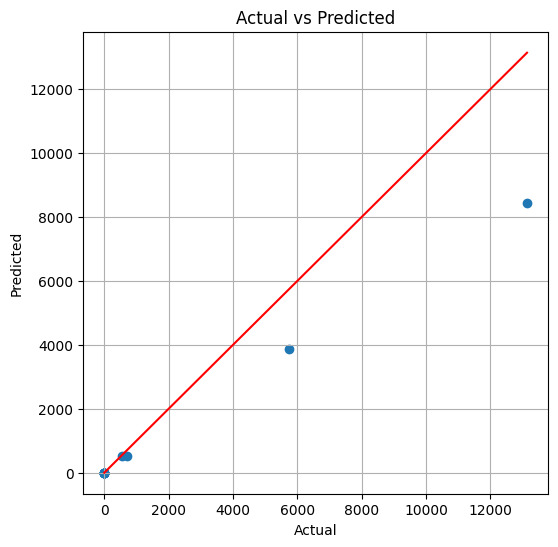

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # perfect line

plt.grid()
plt.show()

In [39]:
import numpy as np

# Transform target
y_log = np.log1p(y)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict (log scale)
y_pred_log = model.predict(X_test)

# Convert back
y_pred = np.expm1(y_pred_log)

# Remove negatives
y_pred = np.maximum(y_pred, 0)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

NameError: name 'y_test_original' is not defined

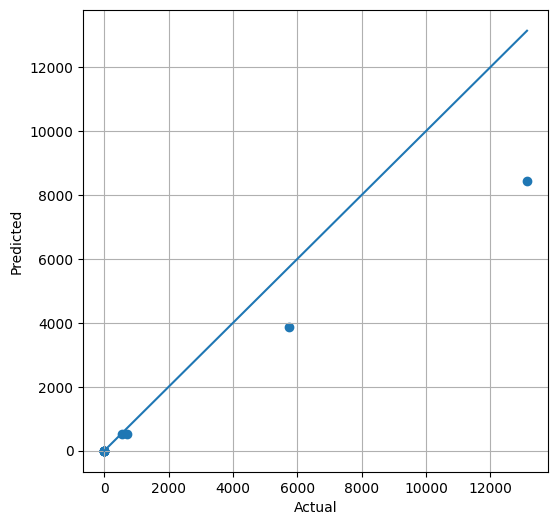

In [40]:
# Convert y_test back to original
y_test_original = np.expm1(y_test)

# Plot correct
plt.figure(figsize=(6,6))
plt.scatter(y_test_original, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()])

plt.grid()
plt.show()

In [41]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

In [42]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model1 = RandomForestRegressor(n_estimators=200)
model2 = XGBRegressor(n_estimators=500, learning_rate=0.03)

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)

# Average
y_pred = (pred1 + pred2) / 2

In [43]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Model 1
rf = RandomForestRegressor(n_estimators=300, random_state=42)

# Model 2
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
# Train on log scale
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Predict (log scale)
pred_rf_log = rf.predict(X_test)
pred_xgb_log = xgb.predict(X_test)

# Combine (log scale)
y_pred_log = (pred_rf_log + pred_xgb_log) / 2

# Convert back to original
import numpy as np
y_pred = np.expm1(y_pred_log)

# Remove negatives
y_pred = np.maximum(y_pred, 0)

In [44]:
y_test_original = np.expm1(y_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 522.336325968771
RMSE: 1453.6258492276136


In [45]:
weights = [(0.3, 0.7), (0.4, 0.6), (0.5, 0.5), (0.2, 0.8)]

for w1, w2 in weights:
    y_pred_log = w1 * pred_rf_log + w2 * pred_xgb_log
    y_pred = np.expm1(y_pred_log)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_test_original, y_pred)
    print(f"Weights RF:{w1}, XGB:{w2} → MAE:", mae)

Weights RF:0.3, XGB:0.7 → MAE: 538.0411823419599
Weights RF:0.4, XGB:0.6 → MAE: 530.220706060789
Weights RF:0.5, XGB:0.5 → MAE: 522.336325968771
Weights RF:0.2, XGB:0.8 → MAE: 545.7940593819915


In [46]:
# Predict on FULL data (IMPORTANT)
X_all = df_filled[features]

pred_rf_log = rf.predict(X_all)
pred_xgb_log = xgb.predict(X_all)

# Combine
y_pred_log = 0.4 * pred_rf_log + 0.6 * pred_xgb_log

# Convert back
import numpy as np
y_pred = np.expm1(y_pred_log)
y_pred = np.maximum(y_pred, 0)

# Now assign (works ✅)
df_filled["Predicted FY26 Q2"] = y_pred

In [47]:
df_filled["Predicted FY26 Q2"].describe()

count       65.000000
mean      3403.609112
std       8105.603683
min          0.000000
25%          0.000000
50%        312.523197
75%       3205.350561
max      50780.218953
Name: Predicted FY26 Q2, dtype: float64

In [48]:
df_filled.sort_values("Predicted FY26 Q2", ascending=False).head(10)

,Cost Rank,Product Name,Product Life Cycle,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,...,growth,Predicted FY26 Q2,lag_1,lag_2,lag_3,lag_4,last_quarter,last_quarter_num,trend,volatility
1,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498.0,40505.0,61214.0,41932.0,59424.0,60073.0,66952.0,...,27820.0,50780.218953,58318.0,71494.0,87843.0,78096.0,58318.0,2,-13176.0,15466.472710
4,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349.0,67670.0,55237.0,53599.0,53108.0,51781.0,59560.0,...,-41161.0,37576.450215,43188.0,41524.0,53710.0,60281.0,43188.0,2,1664.0,11363.878502
21,22,IP PHONE Enterprise Desk,Decline,32314.0,43403.0,41773.0,28746.0,40155.0,33754.0,24936.0,...,-18849.0,12720.468798,13465.0,18955.0,21567.0,24413.0,13465.0,2,-5490.0,9995.627949
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9349.576017,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9349.576017,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
34,NaN,NaN,Accuracy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9349.576017,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
32,Cost Rank,Product Name,Demand Planning Team's Forecast Accuracy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9349.576017,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
33,NaN,NaN,FY2026 Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9349.576017,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
0,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149.0,10584.0,16105.0,12434.0,9437.0,17530.0,18518.0,...,-8005.0,8200.145684,13144.0,18663.0,14395.0,16256.0,13144.0,2,-5519.0,3379.936246
3,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927.0,8358.0,11681.0,10461.0,9704.0,11345.0,9946.0,...,-2494.0,8089.647588,8433.0,10338.0,9436.0,8436.0,8433.0,2,-1905.0,1203.991199


In [50]:
df_filled[["Product Name", "Predicted FY26 Q2"]].to_csv("submission.csv", index=False)

In [51]:
# Remove blank product names
df_filled = df_filled[df_filled["Product Name"].notna()]
df_filled = df_filled[df_filled["Product Name"] != ""]

# Remove duplicates
df_filled = df_filled.drop_duplicates(subset=["Product Name"])

In [52]:
# Only predict rows where FY26 Q2 was missing originally
mask = df_final["FY26 Q2"].isna()

X_predict = df_filled.loc[mask, features]

pred_rf_log = rf.predict(X_predict)
pred_xgb_log = xgb.predict(X_predict)

y_pred_log = 0.4 * pred_rf_log + 0.6 * pred_xgb_log

y_pred = np.expm1(y_pred_log)
y_pred = np.maximum(y_pred, 0)

# Assign only to missing rows
df_filled.loc[mask, "Predicted FY26 Q2"] = y_pred

In [53]:
final_df = df_filled[["Product Name", "Predicted FY26 Q2"]]

# Remove any weird values
final_df = final_df[final_df["Predicted FY26 Q2"] > 1]

final_df.to_csv("submission_clean.csv", index=False)

In [54]:
final_df = df_filled[["Product Name", "Predicted FY26 Q2"]].copy()

# Remove bad rows
final_df = final_df[final_df["Product Name"].notna()]
final_df = final_df[final_df["Product Name"] != ""]
final_df = final_df[final_df["Product Name"] != "Product Name"]

# Remove duplicates (safety)
final_df = final_df.drop_duplicates(subset=["Product Name"])

# Optional: remove very small values (noise)
final_df = final_df[final_df["Predicted FY26 Q2"] > 10]

# Reset index
final_df = final_df.reset_index(drop=True)

# Save final
final_df.to_csv("final_submission.csv", index=False)

In [55]:
final_df.sort_values("Predicted FY26 Q2", ascending=False).head(5)

,Product Name,Predicted FY26 Q2
1,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,50780.218953
4,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,37576.450215
21,IP PHONE Enterprise Desk,12720.468798
30,Product Name,9349.576017
0,SWITCH Enterprise 48-Port UPOE,8200.145684


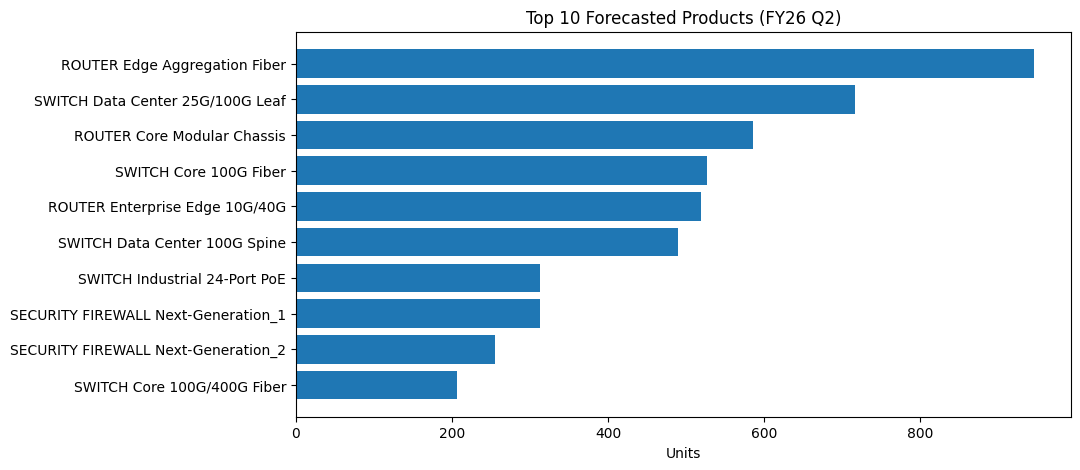

In [56]:
import matplotlib.pyplot as plt

top10 = final_df.sort_values("Predicted FY26 Q2", ascending=False).tail(10)

plt.figure(figsize=(10,5))
plt.barh(top10["Product Name"], top10["Predicted FY26 Q2"])
plt.gca().invert_yaxis()

plt.title("Top 10 Forecasted Products (FY26 Q2)")
plt.xlabel("Units")
plt.show()

In [57]:
print(final_df.sort_values("Predicted FY26 Q2", ascending=False).head(10))

                                         Product Name  Predicted FY26 Q2
1   WIRELESS ACCESS POINT WiFi6E (Internal Antenna...       50780.218953
4   WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...       37576.450215
21                           IP PHONE Enterprise Desk       12720.468798
30                                      Product Name         9349.576017
0                      SWITCH Enterprise 48-Port UPOE        8200.145684
3                      SWITCH Enterprise 24-Port PoE+        8089.647588
18  WIRELESS ACCESS POINT WiFi6 (External Antenna)...        7255.211990
22                           ROUTER Branch 4-Port PoE        6817.262877
2                          SWITCH Core 25G/100G Fiber        5994.996568
13  WIRELESS ACCESS POINT WiFi6E (External Antenna...        4452.335303


In [58]:
print(final_df.sort_values("Predicted FY26 Q2").head(10))

                           Product Name  Predicted FY26 Q2
20          SWITCH Core 100G/400G Fiber         206.364090
10  SECURITY FIREWALL Next-Generation_2         254.496197
14  SECURITY FIREWALL Next-Generation_1         312.523197
28        SWITCH Industrial 24-Port PoE         312.720532
19        SWITCH Data Center 100G Spine         490.084290
9        ROUTER Enterprise Edge 10G/40G         519.184860
12               SWITCH Core 100G Fiber         526.780605
5           ROUTER Core Modular Chassis         584.885673
17     SWITCH Data Center 25G/100G Leaf         716.237205
27        ROUTER Edge Aggregation Fiber         945.345979


In [59]:
top10 = final_df.sort_values("Predicted FY26 Q2", ascending=False).head(10)

top10_compare = top10.merge(
    df_filled[["Product Name", "FY26 Q1"]],
    on="Product Name",
    how="left"
)

top10_compare[["Product Name", "FY26 Q1", "Predicted FY26 Q2"]]

,Product Name,FY26 Q1,Predicted FY26 Q2
0,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,58318.0,50780.218953
1,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,43188.0,37576.450215
2,IP PHONE Enterprise Desk,13465.0,12720.468798
3,Product Name,NaN,9349.576017
4,SWITCH Enterprise 48-Port UPOE,13144.0,8200.145684
5,SWITCH Enterprise 24-Port PoE+,8433.0,8089.647588
6,WIRELESS ACCESS POINT WiFi6 (External Antenna)...,7261.0,7255.211990
7,ROUTER Branch 4-Port PoE,6821.0,6817.262877
8,SWITCH Core 25G/100G Fiber,6346.0,5994.996568
9,WIRELESS ACCESS POINT WiFi6E (External Antenna...,5730.0,4452.335303


In [60]:
bottom10 = final_df.sort_values("Predicted FY26 Q2").head(10)

bottom10_compare = bottom10.merge(
    df_filled[["Product Name", "FY26 Q1"]],
    on="Product Name",
    how="left"
)

bottom10_compare[["Product Name", "FY26 Q1", "Predicted FY26 Q2"]]

,Product Name,FY26 Q1,Predicted FY26 Q2
0,SWITCH Core 100G/400G Fiber,208.0,206.364090
1,SECURITY FIREWALL Next-Generation_2,252.0,254.496197
2,SECURITY FIREWALL Next-Generation_1,326.0,312.523197
3,SWITCH Industrial 24-Port PoE,301.0,312.720532
4,SWITCH Data Center 100G Spine,506.0,490.084290
5,ROUTER Enterprise Edge 10G/40G,530.0,519.184860
6,SWITCH Core 100G Fiber,546.0,526.780605
7,ROUTER Core Modular Chassis,705.0,584.885673
8,SWITCH Data Center 25G/100G Leaf,715.0,716.237205
9,ROUTER Edge Aggregation Fiber,943.0,945.345979


In [61]:
mask = df_filled["FY26 Q1"] > 20000

In [62]:
lower = df_filled["FY26 Q1"] * 0.9
upper = df_filled["FY26 Q1"] * 1.1

In [63]:
df_filled.loc[mask, "Predicted FY26 Q2"] = df_filled.loc[mask, "Predicted FY26 Q2"].clip(
    lower=lower[mask],
    upper=upper[mask]
)

In [64]:
df_filled.sort_values("Predicted FY26 Q2", ascending=False)[
    ["Product Name", "FY26 Q1", "Predicted FY26 Q2"]
].head(30)

,Product Name,FY26 Q1,Predicted FY26 Q2
1,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,58318.0,52486.200000
4,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,43188.0,38869.200000
21,IP PHONE Enterprise Desk,13465.0,12720.468798
32,Product Name,NaN,9349.576017
0,SWITCH Enterprise 48-Port UPOE,13144.0,8200.145684
3,SWITCH Enterprise 24-Port PoE+,8433.0,8089.647588
18,WIRELESS ACCESS POINT WiFi6 (External Antenna)...,7261.0,7255.211990
22,ROUTER Branch 4-Port PoE,6821.0,6817.262877
2,SWITCH Core 25G/100G Fiber,6346.0,5994.996568
13,WIRELESS ACCESS POINT WiFi6E (External Antenna...,5730.0,4452.335303


In [65]:
trend = df_filled["FY26 Q1"] - df_filled["FY25 Q4"]

df_filled["Predicted FY26 Q2"] = (
    0.8 * df_filled["Predicted FY26 Q2"] +
    0.2 * (df_filled["FY26 Q1"] + trend)
)

In [66]:
df_filled["Predicted FY26 Q2"] = (
    0.7 * df_filled["FY26 Q1"] +
    0.3 * df_filled["Predicted FY26 Q2"]
)

In [67]:
df_filled["Predicted FY26 Q2"] = df_filled["Predicted FY26 Q2"].clip(
    lower=0,
    upper=df_filled["FY26 Q1"] * 1.2
)

In [68]:
final_df = df_filled[["Product Name", "Predicted FY26 Q2"]]

final_df = final_df.drop_duplicates(subset=["Product Name"])
final_df = final_df[final_df["Product Name"].notna()]
final_df = final_df[final_df["Product Name"] != ""]

In [69]:
# 🔥 After ALL predictions + adjustments done

# CLEANING (ADD HERE)
df_filled = df_filled[df_filled["Product Name"].notna()]
df_filled = df_filled[df_filled["Product Name"] != "Product Name"]

# FINAL SAVE
final_df = df_filled[["Product Name", "Predicted FY26 Q2"]]

final_df.to_csv("final_submission2.csv", index=False)

In [73]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [74]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("CFL FY26 Q2 Forecasts")

# Load data
df = pd.read_csv("final_submission2.csv")

# Search / filter
query = st.text_input("Search product name (substring)")
if query:
    df_show = df[df["Product Name"].str.contains(query, case=False, na=False)]
else:
    df_show = df.copy()

st.subheader("Predictions (preview)")
st.dataframe(df_show)

# Top N plot
n = st.slider("Top N products to show", 5, 30, 10)
topn = df.sort_values("Predicted FY26 Q2", ascending=False).head(n)
fig, ax = plt.subplots(figsize=(8, max(3, n*0.3)))
ax.barh(topn["Product Name"], topn["Predicted FY26 Q2"])
ax.invert_yaxis()
ax.set_xlabel("Predicted FY26 Q2")
st.pyplot(fig)

# Single-product detail
prod = st.selectbox("Select product", df["Product Name"].dropna().unique())
if prod:
    val = df.loc[df["Product Name"] == prod, "Predicted FY26 Q2"].values
    st.metric("Predicted FY26 Q2", int(val[0]) if len(val) else "N/A")

# Download
st.download_button(
    "Download current CSV",
    data=df_show.to_csv(index=False).encode("utf-8"),
    file_name="predictions_filtered.csv",
    mime="text/csv",
)

2026-04-15 11:47:13.732 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:47:13.733 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:47:13.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:47:13.738 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:47:13.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:47:13.741 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:47:13.742 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 11:47:13.743 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

False